Nama : Mika Khairan Djubikit
NIM  : F1D02310075

In [170]:
import matplotlib.pyplot as plt
import numpy as np
import cv2


### Melakukan import library
Code tersebut mengimpor beberapa library, yaitu:

numpy untuk manipulasi array
cv2 (OpenCV) untuk pengolahan gambar
matplotlib.pyplot untuk menampilkan gambar atau grafik

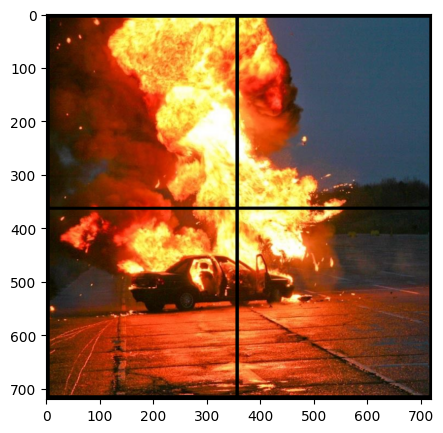

In [171]:
citraA = plt.imread("Assets/Meledak.png")

fig = plt.subplots( figsize=(10, 5))
plt.imshow(citraA)
plt.show()


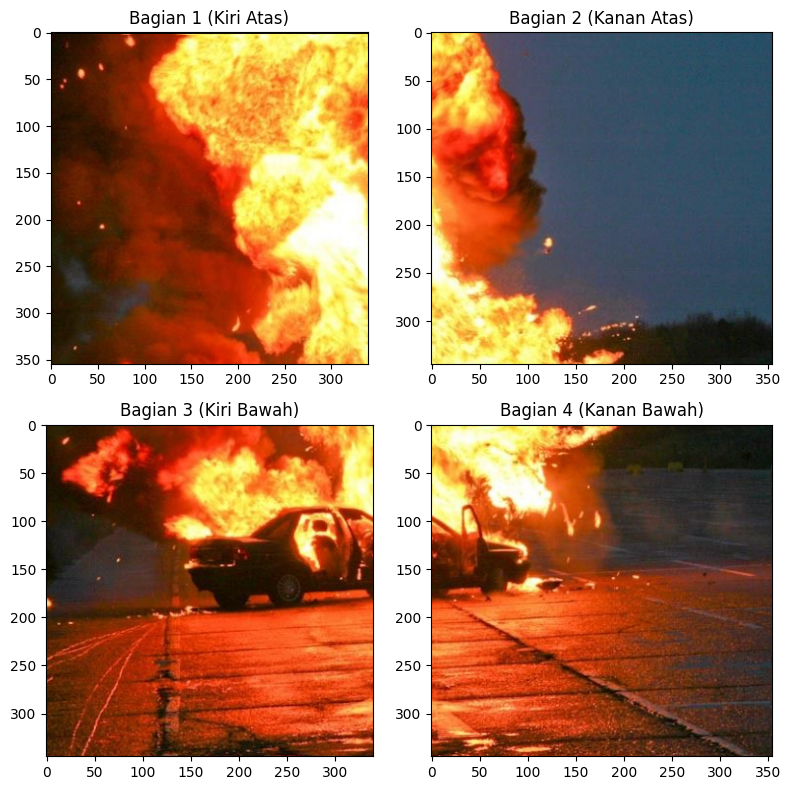

In [172]:

# 1. Baca gambar asli
citraA = cv2.imread('Assets/Meledak.png')
citraA = cv2.cvtColor(citraA, cv2.COLOR_BGR2RGB)

# 2. Ambil ukuran tinggi (h) dan lebar (w)
h, w, _ = citraA.shape

# 3. Tentukan titik tengah
mid_h = h // 2
mid_w = w // 2

# 4. Potong gambar menjadi 4 bagian (Slicing)
part1 = citraA[5:mid_h, 10:mid_w-10]      # Kiri Atas
part2 = citraA[15:mid_h, mid_w:w-5]      # Kanan Atas
part3 = citraA[mid_h+5:h-10, 10:mid_w-10]      # Kiri Bawah
part4 = citraA[mid_h+5:h-10, mid_w:w-5]      # Kanan Bawah

# 5. Tampilkan hasilnya dalam satu jendela untuk mengecek
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs[0, 0].imshow(part1); axs[0, 0].set_title('Bagian 1 (Kiri Atas)')
axs[0, 1].imshow(part2); axs[0, 1].set_title('Bagian 2 (Kanan Atas)')
axs[1, 0].imshow(part3); axs[1, 0].set_title('Bagian 3 (Kiri Bawah)')
axs[1, 1].imshow(part4); axs[1, 1].set_title('Bagian 4 (Kanan Bawah)')

plt.tight_layout()
plt.show()

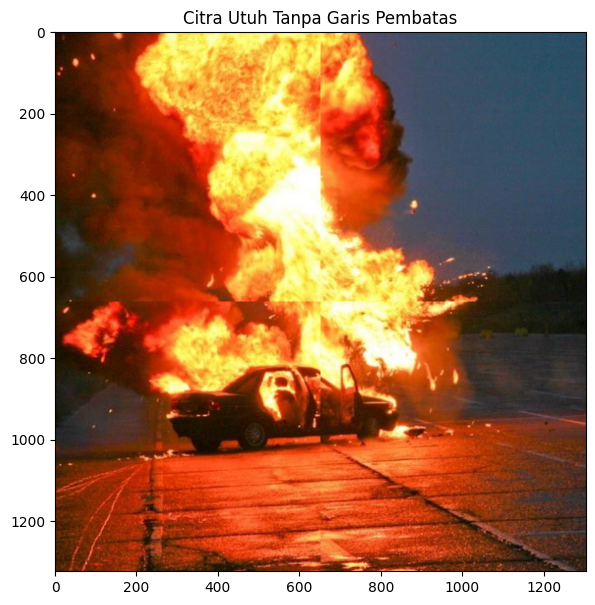

In [173]:
# =======================================================
# PERBAIKAN TAHAP 3: CROP & MERGE
# =======================================================

# 1. Pastikan semua potongan punya ukuran yang sama persis
# Kita cari tinggi (h) dan lebar (w) terkecil dari keempat potongan
h_min = min(c1_crop.shape[0], c2_crop.shape[0], c3_crop.shape[0], c4_crop.shape[0])
w_min = min(c1_crop.shape[1], c2_crop.shape[1], c3_crop.shape[1], c4_crop.shape[1])

# Lakukan slicing ulang agar ukurannya seragam (h_min x w_min)
c1_final = c1_crop[:h_min, :w_min]
c2_final = c2_crop[:h_min, :w_min]
c3_final = c3_crop[:h_min, :w_min]
c4_final = c4_crop[:h_min, :w_min]

# 2. PENGGABUNGAN (SEAMLESS)
# Sekarang hstack dan vstack tidak akan error karena dimensinya sudah match
baris_atas = np.hstack((c1_final, c2_final))
baris_bawah = np.hstack((c3_final, c4_final))
kicau_menyatu = np.vstack((baris_atas, baris_bawah))

# 3. DILATASI (Perbesar 2x lipat)
# Pakai np.repeat sesuai logika lu sebelumnya
kicau_utuh = np.repeat(np.repeat(kicau_menyatu, 2, axis=0), 2, axis=1)

# 4. NORMALISASI
kicau_stabil = kicau_utuh.astype(np.uint8)

# TAMPILKAN HASILNYA
plt.figure(figsize=(7, 7))
plt.imshow(kicau_stabil)
plt.title("Citra Utuh Tanpa Garis Pembatas")
plt.show()

Ukuran grayscale: (1324, 1304)


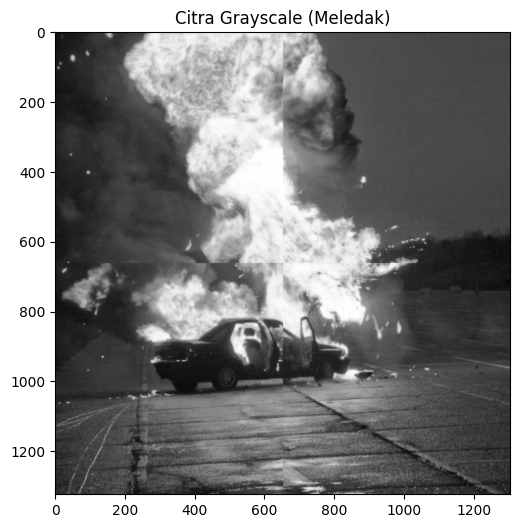

In [174]:
# Pisahkan channel
R = kicau_stabil[:, :, 0].astype(np.float64)
G = kicau_stabil[:, :, 1].astype(np.float64)
B = kicau_stabil[:, :, 2].astype(np.float64)

# Terapkan rumus luminositas secara elemen per elemen (operasi array)
bg_gray = 0.299 * R + 0.587 * G + 0.114 * B
bg_gray = bg_gray.astype(np.uint8)

print(f"Ukuran grayscale: {bg_gray.shape}")

plt.figure(figsize=(6, 6))
plt.imshow(bg_gray, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Grayscale (Meledak)')
plt.show()


Ekualisasi selesai!


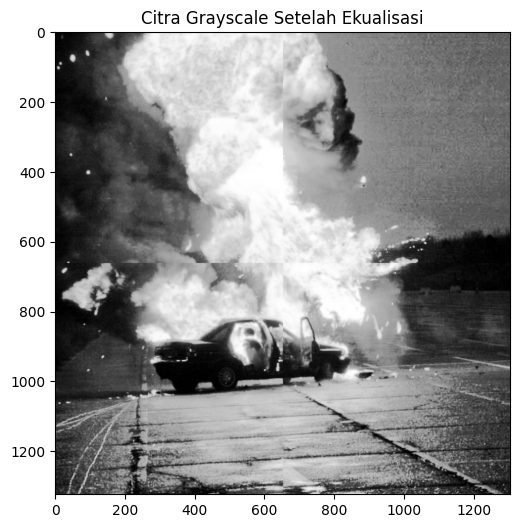

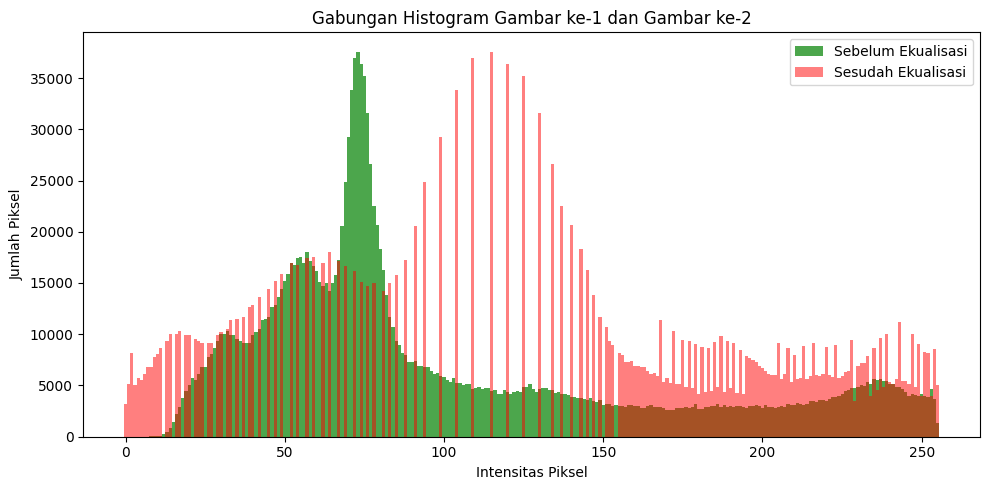

In [175]:
tg, lb = bg_gray.shape
N = tg * lb          # Total piksel

# ---------- A. Hitung Histogram ----------
# Hitung frekuensi setiap nilai intensitas (0–255)
hist_sebelum = np.zeros(256, dtype=np.int64)
for i in range(256):
    hist_sebelum[i] = np.sum(bg_gray == i)

# ---------- B. Hitung CDF Kumulatif ----------
cdf = np.zeros(256, dtype=np.int64)
cdf[0] = hist_sebelum[0]
for i in range(1, 256):
    cdf[i] = cdf[i-1] + hist_sebelum[i]   # Jumlahkan secara bertahap

# ---------- C. Cari CDF minimum yang tidak nol ----------
cdf_min = 0
for i in range(256):
    if cdf[i] > 0:
        cdf_min = cdf[i]
        break

# ---------- D. Buat Lookup Table (tabel pemetaan intensitas) ----------
# Setiap intensitas lama → intensitas baru
lookup = np.zeros(256, dtype=np.uint8)
for i in range(256):
    if (N - cdf_min) > 0:
        # Rumus ekualisasi histogram
        nilai_baru = np.round((cdf[i] - cdf_min) / (N - cdf_min) * 255)
        lookup[i] = int(np.clip(nilai_baru, 0, 255))

# ---------- E. Terapkan Lookup Table ----------
bg_gray_eq = np.zeros((tg, lb), dtype=np.uint8)
for y in range(tg):
    for x in range(lb):
        bg_gray_eq[y, x] = lookup[bg_gray[y, x]]

print("Ekualisasi selesai!")
plt.figure(figsize=(6, 6))
plt.imshow(bg_gray_eq, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Grayscale Setelah Ekualisasi')
plt.show()


# Hitung histogram sesudah ekualisasi
hist_sesudah = np.zeros(256, dtype=np.int64)
for i in range(256):
    hist_sesudah[i] = np.sum(bg_gray_eq == i)

# Tampilkan dalam satu grafik dengan dua warna
plt.figure(figsize=(10, 5))
plt.bar(range(256), hist_sebelum, color='green',  width=1, alpha=0.7, label='Sebelum Ekualisasi')
plt.bar(range(256), hist_sesudah, color='red',    width=1, alpha=0.5, label='Sesudah Ekualisasi')
plt.title('Gabungan Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.legend()
plt.tight_layout()
plt.show()


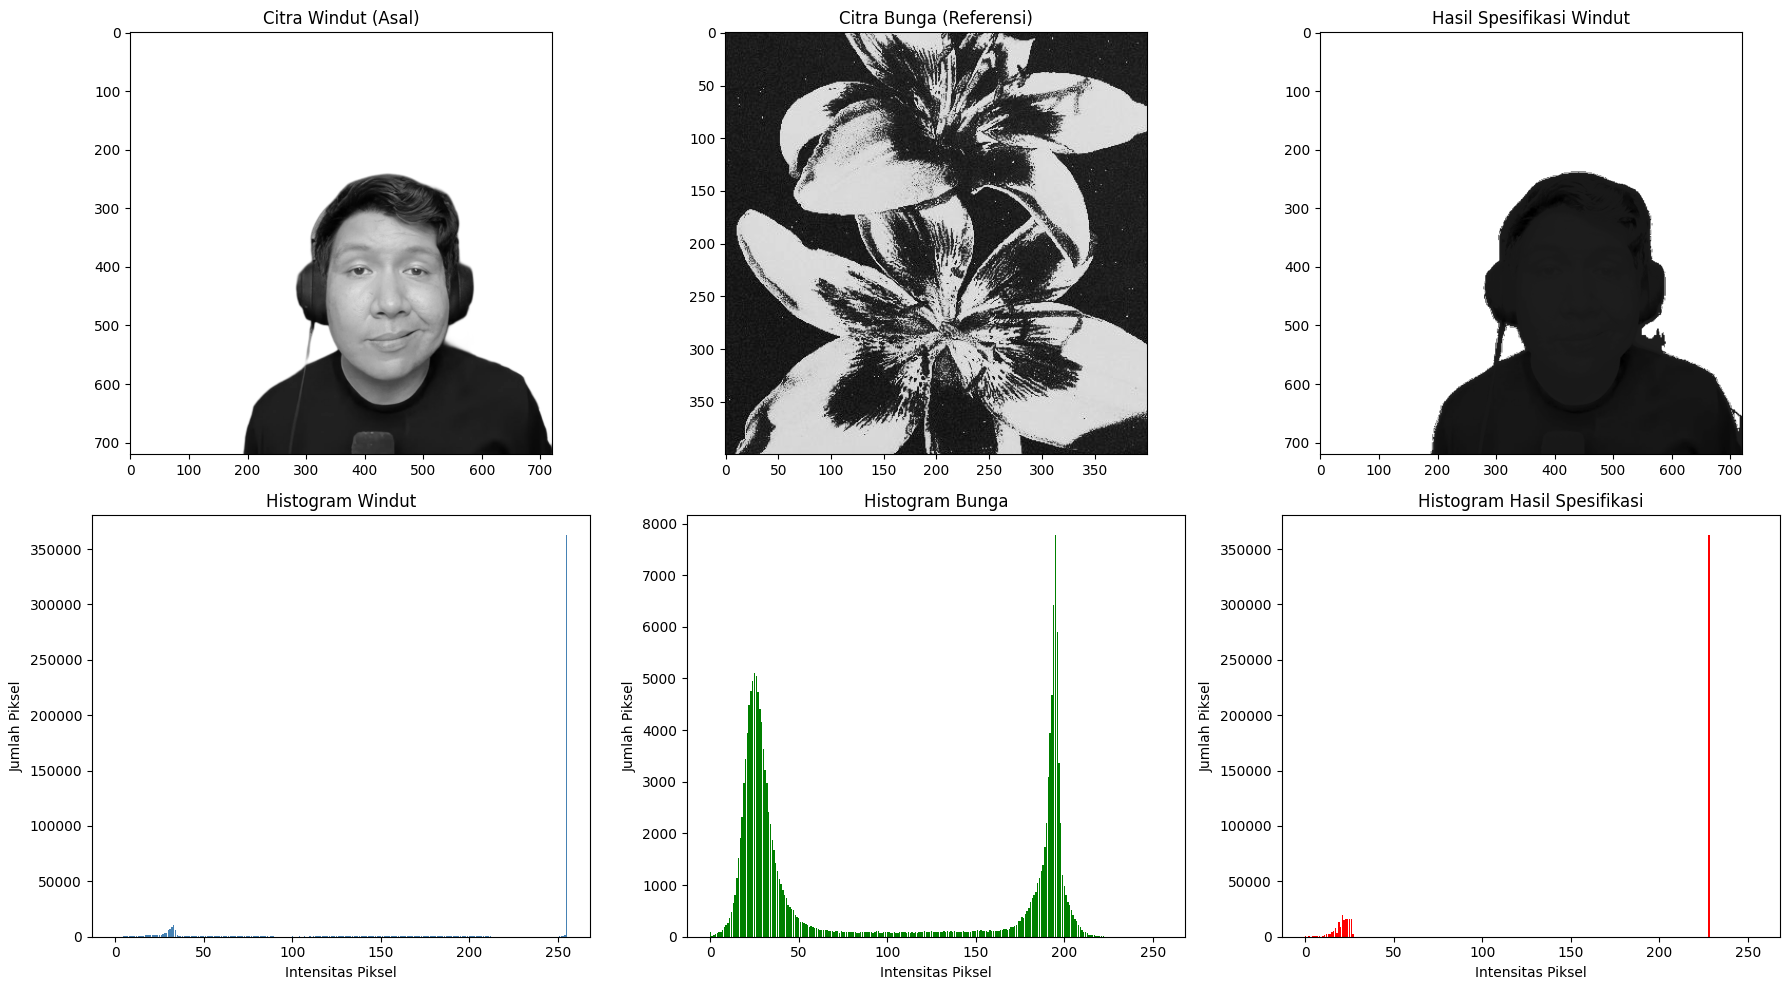

In [176]:
# 1. Baca Citra (Windut & Bunga) [cite: 83, 84]
windut_rgb = cv2.imread('Assets/Windut.png')
windut_rgb = cv2.cvtColor(windut_rgb, cv2.COLOR_BGR2RGB)

bunga_rgb  = cv2.imread('Assets/Bunga.png')
bunga_rgb  = cv2.cvtColor(bunga_rgb,  cv2.COLOR_BGR2RGB)

# 2. Konversi Grayscale Manual (Luminositas) [cite: 64, 105]
def ke_grayscale(img):
    h, w, _ = img.shape
    gray = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            r, g, b = img[i, j]
            # Sesuai instruksi: manual calculation
            gray[i, j] = np.round(0.299*r + 0.587*g + 0.114*b)
    return gray

windut_gray = ke_grayscale(windut_rgb)
bunga_gray  = ke_grayscale(bunga_rgb)

# 3. Fungsi Hitung Histogram & CDF Manual [cite: 74, 106]
def get_cdf_normalized(citra):
    h, w = citra.shape
    hist = np.zeros(256)
    for i in range(h):
        for j in range(w):
            hist[citra[i, j]] += 1
    
    # Hitung CDF (Cumulative Distribution Function)
    cdf = np.zeros(256)
    total_pixel = h * w
    akumulasi = 0
    for i in range(256):
        akumulasi += hist[i]
        cdf[i] = akumulasi / total_pixel
    return hist, cdf

hist_w, cdf_w = get_cdf_normalized(windut_gray)
hist_b, cdf_b = get_cdf_normalized(bunga_gray)

# 4. Spesifikasi Histogram (Histogram Matching) Manual 
# Mencari mapping nilai piksel windut agar mirip bunga
mapping = np.zeros(256, dtype=np.uint8)
for i in range(256):
    # Cari nilai j di cdf_b yang paling dekat dengan cdf_w[i]
    diff = np.abs(cdf_b - cdf_w[i])
    # Cari index dengan selisih terkecil
    idx_min = 0
    min_val = diff[0]
    for k in range(1, 256):
        if diff[k] < min_val:
            min_val = diff[k]
            idx_min = k
    mapping[i] = idx_min

# Terapkan mapping ke citra Windut
h_w, w_w = windut_gray.shape
windut_spesifikasi = np.zeros((h_w, w_w), dtype=np.uint8)
for i in range(h_w):
    for j in range(w_w):
        windut_spesifikasi[i, j] = mapping[windut_gray[i, j]]

# 5. Visualisasi Hasil Spesifikasi [cite: 101, 116]
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Baris 1: Citra
axs[0, 0].imshow(windut_gray, cmap='gray')
axs[0, 0].set_title('Citra Windut (Asal)')

axs[0, 1].imshow(bunga_gray, cmap='gray')
axs[0, 1].set_title('Citra Bunga (Referensi)')

axs[0, 2].imshow(windut_spesifikasi, cmap='gray')
axs[0, 2].set_title('Hasil Spesifikasi Windut')

# Baris 2: Histogram [cite: 106, 125]
axs[1, 0].bar(range(256), hist_w, color='steelblue')
axs[1, 0].set_title('Histogram Windut')

axs[1, 1].bar(range(256), hist_b, color='green')
axs[1, 1].set_title('Histogram Bunga')

# Hitung histogram hasil spesifikasi untuk ditampilkan
hist_res, _ = get_cdf_normalized(windut_spesifikasi)
axs[1, 2].bar(range(256), hist_res, color='red')
axs[1, 2].set_title('Histogram Hasil Spesifikasi')

for ax in axs[1, :]:
    ax.set_xlabel('Intensitas Piksel')
    ax.set_ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

Dimensi Windut Spec: 720x720
Dimensi Background : 1324x1304
Hasil Akhir Crop   : 720x720


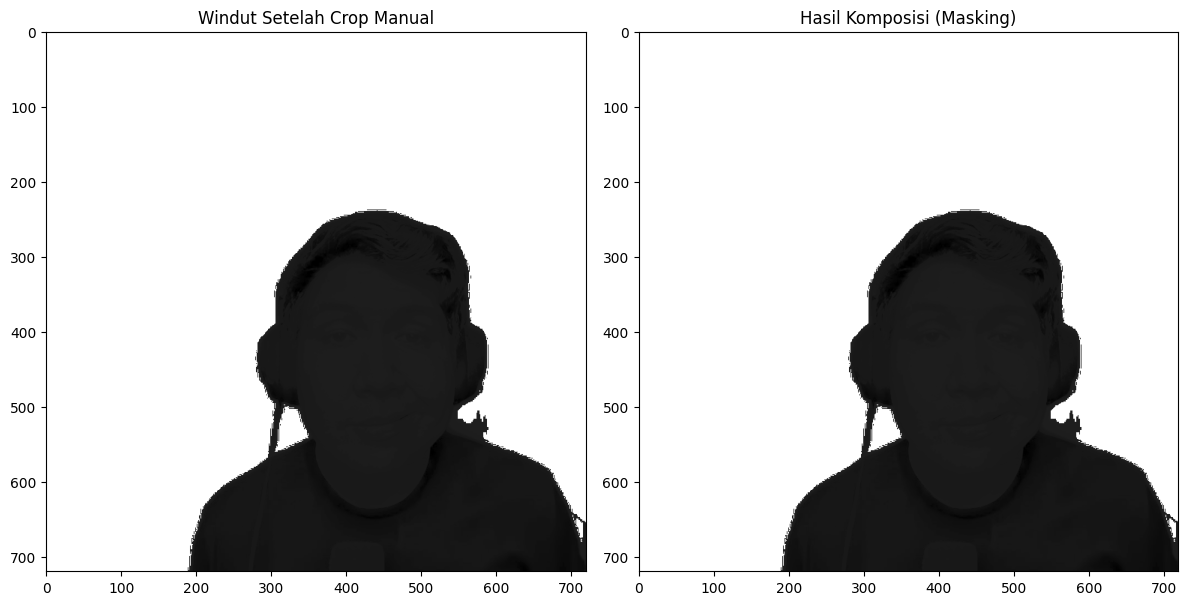

In [177]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 10. CROP MANUAL (MENYAMAKAN DIMENSI)
# ==========================================
# Asumsi:
# windut_spesifikasi = hasil dari Bagian 3
# gray_equalized     = hasil dari Bagian 2 (Meledak grayscale eq)

# Ambil dimensi masing-masing citra
tg_ws, lb_ws = windut_spesifikasi.shape 
tg_bg, lb_bg = bg_gray_eq.shape

# Mencari ukuran terkecil secara manual (tanpa function min)
tg_crop = tg_ws if tg_ws < tg_bg else tg_bg
lb_crop = lb_ws if lb_ws < lb_bg else lb_bg

# Melakukan crop menggunakan slicing array manual [cite: 191]
# Kita potong mulai dari pojok kiri atas (0,0) sampai batas ukuran terkecil
windut_crop = windut_spesifikasi[0:tg_crop, 0:lb_crop]
bg_crop     = bg_gray_eq[0:tg_crop, 0:lb_crop]

print(f"Dimensi Windut Spec: {tg_ws}x{lb_ws}")
print(f"Dimensi Background : {tg_bg}x{lb_bg}")
print(f"Hasil Akhir Crop   : {tg_crop}x{lb_crop}")

# ==========================================
# 11. MASKING & COMPOSITING (PENEMPELAN)
# ==========================================
# Buat kanvas kosong seukuran hasil crop menggunakan np.zeros [cite: 193]
hasil_komposisi = np.zeros((tg_crop, lb_crop), dtype=np.uint8)

# Hint Wajib: Gunakan perulangan for untuk memproses setiap piksel 
# Threshold 240 dipilih karena warna putih mendekati intensitas 255 
threshold_putih = 240 



for i in range(tg_crop):
    for j in range(lb_crop):
        # Ambil nilai intensitas piksel dari citra Windut
        piksel_w = windut_crop[i, j]
        
        # Logika Masking:
        # Jika piksel Windut berwarna putih (>= 240), maka ambil piksel background
        if piksel_w >= threshold_putih:
            hasil_komposisi[i, j] = bg_crop[i, j]
        else:
            # Jika bukan putih, maka pertahankan piksel wajah Windut [cite: 141]
            hasil_komposisi[i, j] = piksel_w

# ==========================================
# VISUALISASI HASIL
# ==========================================
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(windut_crop, cmap='gray')
plt.title('Windut Setelah Crop Manual')

plt.subplot(1, 2, 2)
plt.imshow(hasil_komposisi, cmap='gray')
plt.title('Hasil Komposisi (Masking)')

plt.tight_layout()
plt.show()
